# Water Segmentation, Week 2: Pretrained Encoders
- Goal: beat the Week 1 scratch U-Net with ImageNet-pretrained encoders, 12-channel input
- Week 1 reference to beat (val IoU, 5 seeds): engineered 0.7573 ± 0.0017, baseline 0.7485 ± 0.0137
- Scratch U-Net, trainer settings and full-water definition now match your Week 1 notebook

## 1. Setup and data loading
- Mount Drive, install smp, load Week 1 arrays and split
- Print the Week 1 reference

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip install -q segmentation-models-pytorch tabulate

import copy
import inspect
import json
import os
import random
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as nnf
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset

SEED = 42
ROOT = Path("/content/drive/MyDrive/water_seg")
SAVE_DIR = ROOT / "data"
RUNS_DIR = ROOT / "runs_w2"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

ids = json.load(open(SAVE_DIR / "ids.json"))
band_names = json.load(open(SAVE_DIR / "feature_names_12.json"))
F12 = np.load(SAVE_DIR / "features_12.npy")
Y = np.load(SAVE_DIR / "masks.npy")
meta = pd.read_csv(ROOT / "split.csv")
assert meta["id"].astype(str).tolist() == ids
idx = {s: np.where(meta["split"].to_numpy() == s)[0] for s in ["train", "val", "test"]}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "no GPU")
print("torch:", torch.__version__, "| smp:", smp.__version__)
print("F12:", F12.shape, F12.dtype, "| Y:", Y.shape, Y.dtype)
print("NaN in F12:", bool(np.isnan(F12).any()), "| range:", float(F12.min()), float(F12.max()))
print("channel order:", band_names)
print()
for s in idx:
    print(f"{s}: {len(idx[s])} images, water {Y[idx[s]].mean() * 100:.2f}%")

ref_path = ROOT / "seed_results.csv"
print()
if ref_path.exists():
    ref = pd.read_csv(ref_path)
    print("Week 1 reference (val, 5 seeds):")
    print(ref.groupby("variant")[["iou", "f1", "precision", "recall"]].agg(["mean", "std"]).round(4).to_string())
else:
    ref = None
    print("seed_results.csv not found, Week 1 rows will be skipped in the tables")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.9 MB/s eta 0:00:00
device: cuda | Tesla T4
torch: 2.11.0+cu130 | smp: 0.5.0
F12: (306, 12, 128, 128) float32 | Y: (306, 128, 128) uint8
NaN in F12: False | range: 0.0 1.0
channel order: ['Coastal', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA', 'MeritDEM', 'CopDEM', 'ESA', 'WaterOcc']

train: 213 images, water 26.41%
val: 47 images, water 26.31%
test: 46 images, water 23.63%

Week 1 reference (val, 5 seeds):
               iou              f1         precision          recall        
              mean     std    mean     std      mean     std    mean     std
variant                                                                     
baseline    0.7485  0.0137  0.8561  0.0090    0.8951  0.0396  0.8219  0.0203
engineered  0.7573  0.0017  0.8619  0.0011    0.9217  0.0075  0.8095  0.0045


## 2. Backbone ranking (hypotheses until the runs finish)
1. ResNet34: best balance of capacity and stability
2. ResNet18: safest on 213 images, less capacity
3. EfficientNet-b0: capacity-matched to the scratch model (about 6M vs 7.77M), more LR sensitive
4. ResNet50: highest overfitting risk, optional
5. EfficientNet-b2 to b3: only if b0 shows promise
6. Satellite-pretrained ResNet (SSL4EO): band mapping unclear, future work

### Recipe
- First layer: `avg` or `rgb_zero` (RGB filters to array indices 3, 2, 1, zeros elsewhere)
- Z-score per channel with train-only statistics
- AdamW, weight decay 1e-2 (none on BatchNorm and bias), encoder LR 1e-4, decoder LR 1e-3
- Scratch U-Net re-run on the same input and weight decay as a control

## 3. Encoder names and weights
- Pick the EfficientNet-b0 name that loads in your smp version
- Check: all rows OK

In [2]:
ENCODER_NAMES = {"resnet18": "resnet18", "resnet34": "resnet34", "resnet50": "resnet50", "effb0": None}
effb0_options = ["efficientnet-b0", "timm-efficientnet-b0", "tu-efficientnet_b0"]

for name in effb0_options:
    try:
        m = smp.Unet(name, encoder_weights="imagenet", in_channels=3, classes=1)
        ENCODER_NAMES["effb0"] = name
        print(f"effb0 resolved to {name}")
        break
    except Exception as e:
        print(f"{name:24s} FAIL {type(e).__name__}: {str(e)[:90]}")
assert ENCODER_NAMES["effb0"] is not None, "no EfficientNet-b0 name worked in this smp version"

print()
for key, name in ENCODER_NAMES.items():
    m = smp.Unet(name, encoder_weights="imagenet", in_channels=3, classes=1)
    n = sum(p.numel() for p in m.parameters())
    first = next(mod for mod in m.encoder.modules() if isinstance(mod, nn.Conv2d))
    print(f"{key:10s} {name:22s} OK  {n / 1e6:6.2f}M params | first conv weight {tuple(first.weight.shape)}")
    del m

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

effb0 resolved to efficientnet-b0



config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

...

resnet34   resnet34               OK   24.44M params | first conv weight (64, 3, 7, 7)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

resnet50   resnet50               OK   32.52M params | first conv weight (64, 3, 7, 7)
effb0      efficientnet-b0        OK    6.25M params | first conv weight (32, 3, 3, 3)


## 4. Standardization
- Convert to (N, 12, H, W) and masks to (N, H, W)
- Z-score with train statistics only
- Check: train mean about 0, std about 1, no NaN

In [3]:
def to_nchw(a, n_ch):
    if a.ndim == 4 and a.shape[1] == n_ch:
        return a
    if a.ndim == 4 and a.shape[-1] == n_ch:
        return np.transpose(a, (0, 3, 1, 2))
    raise ValueError(f"cannot find the channel axis in {a.shape}")


X12 = np.ascontiguousarray(to_nchw(F12, 12)).astype(np.float32)
Ym = Y.astype(np.float32)
if Ym.ndim == 4:
    Ym = Ym[:, 0] if Ym.shape[1] == 1 else Ym[..., 0]
Ym = np.ascontiguousarray(Ym)

N, _, H, W = X12.shape
assert Ym.shape == (N, H, W), Ym.shape
assert set(np.unique(Ym).tolist()) <= {0.0, 1.0}, "masks are not binary"
print("X12:", X12.shape, X12.dtype, "| Ym:", Ym.shape, Ym.dtype, "| unique mask values:", np.unique(Ym).tolist())

RGB_IDX = [3, 2, 1]
print("pretrained R, G, B filters will map to array indices", RGB_IDX, "->", [band_names[i] for i in RGB_IDX])

tr = idx["train"]
mean12 = X12[tr].mean(axis=(0, 2, 3))
std12 = X12[tr].std(axis=(0, 2, 3))
std12_safe = np.where(std12 < 1e-6, 1.0, std12).astype(np.float32)
Xz = ((X12 - mean12[None, :, None, None]) / std12_safe[None, :, None, None]).astype(np.float32)

json.dump({"mean": mean12.tolist(), "std": std12_safe.tolist(), "bands": band_names}, open(SAVE_DIR / "norm_stats_z12.json", "w"))

rows = []
for c in range(12):
    rows.append(dict(
        band=band_names[c],
        train_mean=Xz[idx["train"], c].mean(), train_std=Xz[idx["train"], c].std(),
        val_mean=Xz[idx["val"], c].mean(), val_std=Xz[idx["val"], c].std(),
        test_mean=Xz[idx["test"], c].mean(), test_std=Xz[idx["test"], c].std(),
        min=Xz[:, c].min(), max=Xz[:, c].max(),
    ))
print()
print(pd.DataFrame(rows).round(3).to_string(index=False))

print()
print("Xz:", Xz.shape, Xz.dtype, "| NaN:", bool(np.isnan(Xz).any()), "| global range:", float(Xz.min()), float(Xz.max()))
print("train mean max abs:", float(np.abs(Xz[tr].mean(axis=(0, 2, 3))).max()), "| train std range:", float(Xz[tr].std(axis=(0, 2, 3)).min()), float(Xz[tr].std(axis=(0, 2, 3)).max()))
print("constant channels (std < 1e-6):", [band_names[i] for i in np.where(std12 < 1e-6)[0]])
print("channels with |z| > 15 somewhere:", [band_names[i] for i in range(12) if np.abs(Xz[:, i]).max() > 15])

X12: (306, 12, 128, 128) float32 | Ym: (306, 128, 128) float32 | unique mask values: [0.0, 1.0]
pretrained R, G, B filters will map to array indices [3, 2, 1] -> ['Red', 'Green', 'Blue']

    band  train_mean  train_std  val_mean  val_std  test_mean  test_std    min    max
 Coastal        -0.0        1.0    -0.076    0.678      0.023     0.703 -1.616 13.598
    Blue        -0.0        1.0    -0.066    0.659     -0.001     0.741 -1.509 12.881
   Green         0.0        1.0    -0.131    0.686      0.002     0.852 -1.726 10.916
     Red         0.0        1.0    -0.166    0.749     -0.013     1.013 -1.733  8.193
     NIR        -0.0        1.0    -0.173    0.957      0.134     0.944 -2.049  3.202
   SWIR1         0.0        1.0    -0.096    0.917      0.121     1.029 -1.701  2.713
   SWIR2         0.0        1.0    -0.110    0.864      0.109     1.097 -1.436  3.188
      QA        -0.0        1.0     0.058    1.075     -0.055     1.054 -0.809  3.185
MeritDEM        -0.0        1.0    -0.

## 5. Data pipeline
- Paired flips and 90 degree rotations, train only
- Check: shapes, image and mask stay aligned

In [4]:
class SegDataset(Dataset):
    def __init__(self, X, Y, indices, augment=False):
        self.X = torch.from_numpy(np.ascontiguousarray(X[indices]))
        self.Y = torch.from_numpy(np.ascontiguousarray(Y[indices])).unsqueeze(1)
        self.augment = augment

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        x, y = self.X[i], self.Y[i]
        if self.augment:
            if torch.rand(1).item() < 0.5:
                x, y = x.flip(-1), y.flip(-1)
            if torch.rand(1).item() < 0.5:
                x, y = x.flip(-2), y.flip(-2)
            k = int(torch.randint(0, 4, (1,)).item())
            if k:
                x, y = torch.rot90(x, k, (-2, -1)), torch.rot90(y, k, (-2, -1))
        return x.contiguous(), y.contiguous()


DATA = {"z12": {"X": Xz, "Y": Ym}}

ds = SegDataset(Xz, Ym, idx["train"], augment=True)
x0, y0 = ds[0]
print("sample shapes:", tuple(x0.shape), tuple(y0.shape), "| dtypes:", x0.dtype, y0.dtype)

fake = np.zeros((N, 12, H, W), dtype=np.float32)
fake[:, 0] = Ym
ds_fake = SegDataset(fake, Ym, idx["train"], augment=True)
ok = True
for i in range(60):
    xf, yf = ds_fake[i % len(ds_fake)]
    ok = ok and bool(torch.equal(xf[0:1], yf))
print("image and mask stay aligned under augmentation:", ok)

dl = DataLoader(ds, batch_size=16, shuffle=True)
xb, yb = next(iter(dl))
print("batch:", tuple(xb.shape), tuple(yb.shape), "| x range:", round(xb.min().item(), 2), round(xb.max().item(), 2), "| y unique:", torch.unique(yb).tolist())
del fake, ds_fake, dl

sample shapes: (12, 128, 128) (1, 128, 128) | dtypes: torch.float32 torch.float32
image and mask stay aligned under augmentation: True
batch: (16, 12, 128, 128) (16, 1, 128, 128) | x range: -2.05 13.6 | y unique: [0.0, 1.0]


## 6. Metrics and loss
- Pooled IoU, F1, precision, recall at 0.5, same as Week 1
- IoU without full-water images: images above 95% water are dropped, same definition as Week 1
- Check: perfect prediction gives IoU 1, full-water counts match Week 1 (train 8, val 2, test 0)

In [5]:
def pooled_metrics(probs, masks, thr=0.5):
    pred = probs >= thr
    gt = masks >= 0.5
    tp = float(np.logical_and(pred, gt).sum())
    fp = float(np.logical_and(pred, ~gt).sum())
    fn = float(np.logical_and(~pred, gt).sum())
    eps = 1e-9
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return {
        "iou": tp / (tp + fp + fn + eps),
        "f1": 2 * precision * recall / (precision + recall + eps),
        "precision": precision,
        "recall": recall,
    }


def iou_without_full_water(probs, masks, thr=0.5):
    keep = masks.reshape(len(masks), -1).mean(axis=1) <= 0.95
    if keep.sum() == 0:
        return float("nan")
    return pooled_metrics(probs[keep], masks[keep], thr)["iou"]


def per_image_iou(probs, masks, thr=0.5):
    pred = (probs >= thr).reshape(len(probs), -1)
    gt = (masks >= 0.5).reshape(len(masks), -1)
    inter = np.logical_and(pred, gt).sum(axis=1)
    union = np.logical_or(pred, gt).sum(axis=1)
    return np.where(union == 0, 1.0, inter / np.maximum(union, 1))


def seg_loss(logits, target, dice_weight=0.0):
    bce = nnf.binary_cross_entropy_with_logits(logits, target)
    if dice_weight <= 0:
        return bce
    p = torch.sigmoid(logits)
    inter = (p * target).sum()
    dice = 1.0 - (2.0 * inter + 1.0) / (p.sum() + target.sum() + 1.0)
    return bce + dice_weight * dice


gt_t = Ym[idx["val"]]
print("perfect:", {k: round(v, 4) for k, v in pooled_metrics(gt_t, gt_t).items()})
print("inverted:", {k: round(v, 4) for k, v in pooled_metrics(1.0 - gt_t, gt_t).items()})
print("per-image IoU on perfect prediction, min:", float(per_image_iou(gt_t, gt_t).min()))
print("iou without full-water images (perfect):", iou_without_full_water(gt_t, gt_t))
print("images above 95% water per split (Week 1: train 8, val 2, test 0):", {k: int((Ym[v].reshape(len(v), -1).mean(axis=1) > 0.95).sum()) for k, v in idx.items()})
lg = torch.randn(4, 1, 16, 16)
tg = (torch.rand(4, 1, 16, 16) > 0.5).float()
print("loss plain BCE:", round(seg_loss(lg, tg, 0.0).item(), 4), "| with dice 0.5:", round(seg_loss(lg, tg, 0.5).item(), 4))

perfect: {'iou': 1.0, 'f1': 1.0, 'precision': 1.0, 'recall': 1.0}
inverted: {'iou': 0.0, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0}
per-image IoU on perfect prediction, min: 1.0
iou without full-water images (perfect): 0.9999999999999942
images above 95% water per split (Week 1: train 8, val 2, test 0): {'train': 8, 'val': 2, 'test': 0}
loss plain BCE: 0.837 | with dice 0.5: 1.0892


## 7. Models
- Scratch U-Net, plus pretrained U-Net with explicit first-layer adaptation
- Check: max diff about 0 for both strategies, output (B, 1, 128, 128), parameter counts

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetScratch(nn.Module):
    def __init__(self, in_ch, base=32, n_out=1):
        super().__init__()
        c = [base, base * 2, base * 4, base * 8, base * 16]
        self.enc1 = DoubleConv(in_ch, c[0])
        self.enc2 = DoubleConv(c[0], c[1])
        self.enc3 = DoubleConv(c[1], c[2])
        self.enc4 = DoubleConv(c[2], c[3])
        self.bottleneck = DoubleConv(c[3], c[4])
        self.pool = nn.MaxPool2d(2)
        self.up4 = nn.ConvTranspose2d(c[4], c[3], 2, stride=2)
        self.dec4 = DoubleConv(c[3] * 2, c[3])
        self.up3 = nn.ConvTranspose2d(c[3], c[2], 2, stride=2)
        self.dec3 = DoubleConv(c[2] * 2, c[2])
        self.up2 = nn.ConvTranspose2d(c[2], c[1], 2, stride=2)
        self.dec2 = DoubleConv(c[1] * 2, c[1])
        self.up1 = nn.ConvTranspose2d(c[1], c[0], 2, stride=2)
        self.dec1 = DoubleConv(c[0] * 2, c[0])
        self.head = nn.Conv2d(c[0], n_out, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


def find_first_conv(encoder, in_channels=3):
    for name, m in encoder.named_modules():
        if isinstance(m, nn.Conv2d) and m.in_channels == in_channels:
            return name, m
    raise RuntimeError(f"no {in_channels}-channel conv found in the encoder")


def set_module(root, dotted, new):
    parts = dotted.split(".")
    parent = root
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], new)


def adapt_first_conv(model, strategy, in_ch):
    name, conv = find_first_conv(model.encoder)
    w = conv.weight.data.clone()
    if strategy == "avg":
        new_w = w.mean(dim=1, keepdim=True).repeat(1, in_ch, 1, 1) * (3.0 / in_ch)
    elif strategy == "rgb_zero":
        if in_ch <= max(RGB_IDX):
            raise ValueError("rgb_zero needs the 12-channel layout")
        new_w = torch.zeros(w.shape[0], in_ch, *w.shape[2:], dtype=w.dtype)
        for src, dst in enumerate(RGB_IDX):
            new_w[:, dst] = w[:, src]
    else:
        raise ValueError(f"unknown strategy {strategy}")
    new_conv = copy.deepcopy(conv)
    new_conv.weight = nn.Parameter(new_w)
    new_conv.in_channels = in_ch
    set_module(model.encoder, name, new_conv)
    return model


def build_model(cfg, pretrained=True):
    if cfg["kind"] == "scratch":
        return UNetScratch(in_ch=cfg["in_ch"], base=32)
    base = smp.Unet(
        ENCODER_NAMES[cfg["encoder"]],
        encoder_weights="imagenet" if pretrained else None,
        in_channels=3,
        classes=1,
    )
    return adapt_first_conv(base, cfg["strategy"], cfg["in_ch"])


def count_params(model):
    return sum(p.numel() for p in model.parameters())


torch.manual_seed(0)
nonrgb = [i for i in range(12) if i not in RGB_IDX]
tests = []
for key in ["resnet18", "effb0"]:
    base3 = smp.Unet(ENCODER_NAMES[key], encoder_weights="imagenet", in_channels=3, classes=1).eval()
    m_zero = adapt_first_conv(copy.deepcopy(base3), "rgb_zero", 12).eval()
    m_avg = adapt_first_conv(copy.deepcopy(base3), "avg", 12).eval()
    x12 = torch.randn(2, 12, 128, 128)
    img = torch.randn(2, 1, 128, 128)
    with torch.no_grad():
        d_zero = (base3(x12[:, RGB_IDX]) - m_zero(x12)).abs().max().item()
        d_avg = (base3(img.repeat(1, 3, 1, 1)) - m_avg(img.repeat(1, 12, 1, 1))).abs().max().item()
    c_zero = find_first_conv(m_zero.encoder, 12)[1].weight
    c_avg = find_first_conv(m_avg.encoder, 12)[1].weight
    tests.append(dict(
        encoder=key,
        rgb_zero_max_diff=d_zero,
        avg_max_diff=d_avg,
        zero_weight_shape=tuple(c_zero.shape),
        nonrgb_all_zero=bool((c_zero[:, nonrgb] == 0).all()),
        avg_channels_identical=bool(torch.allclose(c_avg[:, 0], c_avg[:, 11])),
    ))
    del base3, m_zero, m_avg
print(pd.DataFrame(tests).to_string(index=False))
print("both max diffs should be about 0 (below 1e-4)")

print()
rows = []
for key in ["resnet18", "resnet34", "resnet50", "effb0"]:
    for strat in ["avg", "rgb_zero"]:
        cfg = dict(kind="pretrained", encoder=key, strategy=strat, in_ch=12)
        m = build_model(cfg).eval()
        with torch.no_grad():
            out = m(torch.randn(2, 12, H, W))
        rows.append(dict(model=key, strategy=strat, params_M=round(count_params(m) / 1e6, 2), out_shape=tuple(out.shape), finite=bool(torch.isfinite(out).all())))
        del m
m = UNetScratch(12, 32).eval()
with torch.no_grad():
    out = m(torch.randn(2, 12, H, W))
rows.append(dict(model="scratch_unet", strategy="none", params_M=round(count_params(m) / 1e6, 2), out_shape=tuple(out.shape), finite=bool(torch.isfinite(out).all())))
del m
print(pd.DataFrame(rows).to_string(index=False))

 encoder  rgb_zero_max_diff  avg_max_diff zero_weight_shape  nonrgb_all_zero  avg_channels_identical
resnet18           0.000003      0.000009    (64, 12, 7, 7)             True                    True
   effb0           0.000031      0.000059    (32, 12, 3, 3)             True                    True
both max diffs should be about 0 (below 1e-4)

       model strategy  params_M        out_shape  finite
    resnet18      avg     14.36 (2, 1, 128, 128)    True
    resnet18 rgb_zero     14.36 (2, 1, 128, 128)    True
    resnet34      avg     24.46 (2, 1, 128, 128)    True
    resnet34 rgb_zero     24.46 (2, 1, 128, 128)    True
    resnet50      avg     32.55 (2, 1, 128, 128)    True
    resnet50 rgb_zero     32.55 (2, 1, 128, 128)    True
       effb0      avg      6.25 (2, 1, 128, 128)    True
       effb0 rgb_zero      6.25 (2, 1, 128, 128)    True
scratch_unet     none      7.77 (2, 1, 128, 128)    True


## 8. Trainer
- Settings in BASE_CFG, finished runs are skipped on rerun
- Saves best.pt, history.csv, val_probs.npy, result.json

In [7]:
BASE_CFG = dict(
    kind="pretrained",
    encoder="resnet34",
    strategy="rgb_zero",
    in_ch=12,
    data="z12",
    epochs=100,
    patience=15,
    batch=16,
    lr_enc=1e-4,
    lr_dec=1e-3,
    wd=1e-2,
    dice_weight=0.0,
    sched_patience=5,
    sched_factor=0.5,
    seed=42,
)


def cfg_of(**kw):
    c = dict(BASE_CFG)
    c.update(kw)
    return c


def run_name_of(c):
    core = "scratch_unet" if c["kind"] == "scratch" else f"{c['encoder']}_{c['strategy']}"
    return f"{core}_{c['data']}_wd{c['wd']:g}_dw{c['dice_weight']:g}_s{c['seed']}"


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def param_groups(model, cfg):
    enc_ids = {id(p) for p in model.encoder.parameters()} if hasattr(model, "encoder") else set()
    buckets = {}
    for _, p in model.named_parameters():
        if not p.requires_grad:
            continue
        part = "enc" if id(p) in enc_ids else "dec"
        buckets.setdefault((part, p.ndim > 1), []).append(p)
    groups = []
    for (part, decay), ps in buckets.items():
        groups.append(dict(
            params=ps,
            lr=cfg["lr_enc"] if part == "enc" else cfg["lr_dec"],
            weight_decay=cfg["wd"] if decay else 0.0,
        ))
    return groups


@torch.no_grad()
def predict(model, Xt, Yt=None, dice_weight=0.0, bs=32):
    model.eval()
    probs = []
    total = 0.0
    for i in range(0, len(Xt), bs):
        xb = Xt[i:i + bs].to(device)
        lg = model(xb)
        probs.append(torch.sigmoid(lg)[:, 0].cpu().numpy())
        if Yt is not None:
            yb = torch.from_numpy(np.ascontiguousarray(Yt[i:i + bs])).unsqueeze(1).to(device)
            total += seg_loss(lg, yb, dice_weight).item() * len(xb)
    probs = np.concatenate(probs)
    return probs, (total / len(Xt) if Yt is not None else None)


def fit(run_name, cfg, data, log_every=10):
    run_dir = RUNS_DIR / run_name
    res_path = run_dir / "result.json"
    if res_path.exists():
        return json.load(open(res_path))
    run_dir.mkdir(parents=True, exist_ok=True)
    set_seed(cfg["seed"])
    X, Yd = data["X"], data["Y"]
    train_ds = SegDataset(X, Yd, idx["train"], augment=True)
    gen = torch.Generator().manual_seed(cfg["seed"])
    loader = DataLoader(train_ds, batch_size=cfg["batch"], shuffle=True, generator=gen)
    Xv = torch.from_numpy(np.ascontiguousarray(X[idx["val"]]))
    Yv = np.ascontiguousarray(Yd[idx["val"]])

    model = build_model(cfg).to(device)
    n_params = count_params(model)
    opt = torch.optim.AdamW(param_groups(model, cfg))
    sched = ReduceLROnPlateau(opt, mode="max", factor=cfg["sched_factor"], patience=cfg["sched_patience"])

    best_iou, best_ep, bad = -1.0, 0, 0
    hist = []
    t_start = time.time()
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        tl, n = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = seg_loss(model(xb), yb, cfg["dice_weight"])
            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite loss in {run_name} at epoch {ep}")
            loss.backward()
            opt.step()
            tl += loss.item() * xb.size(0)
            n += xb.size(0)
        probs, vl = predict(model, Xv, Yv, cfg["dice_weight"])
        m = pooled_metrics(probs, Yv)
        sched.step(m["iou"])
        hist.append(dict(epoch=ep, train_loss=tl / n, val_loss=vl, lr_g0=opt.param_groups[0]["lr"], **m))
        if m["iou"] > best_iou + 1e-4:
            best_iou, best_ep, bad = m["iou"], ep, 0
            torch.save(model.state_dict(), run_dir / "best.pt")
        else:
            bad += 1
        if log_every and ep % log_every == 0:
            print(f"  {run_name} ep {ep:3d} train {tl / n:.4f} val {vl:.4f} iou {m['iou']:.4f} best {best_iou:.4f}@{best_ep}")
        if bad >= cfg["patience"]:
            break

    model.load_state_dict(torch.load(run_dir / "best.pt", map_location=device))
    probs, vl = predict(model, Xv, Yv, cfg["dice_weight"])
    assert probs.shape == Yv.shape, (probs.shape, Yv.shape)
    assert 0.0 <= float(probs.min()) and float(probs.max()) <= 1.0
    m = pooled_metrics(probs, Yv)
    m["iou_no_full"] = iou_without_full_water(probs, Yv)
    if abs(m["iou"] - best_iou) > 1e-3:
        print(f"  warning: reloaded best IoU {m['iou']:.4f} differs from tracked {best_iou:.4f}")
    np.save(run_dir / "val_probs.npy", probs.astype(np.float16))
    pd.DataFrame(hist).to_csv(run_dir / "history.csv", index=False)
    result = dict(
        run_name=run_name, cfg=cfg, params=n_params, best_epoch=best_ep, epochs_run=len(hist),
        seconds=round(time.time() - t_start, 1), val=m,
    )
    json.dump(result, open(res_path, "w"))
    del model, opt
    torch.cuda.empty_cache()
    return result


def run(log_every=10, **kw):
    c = cfg_of(**kw)
    name = run_name_of(c)
    r = fit(name, c, DATA[c["data"]], log_every=log_every)
    v = r["val"]
    print(f"{name}: iou {v['iou']:.4f} f1 {v['f1']:.4f} best epoch {r['best_epoch']} of {r['epochs_run']} in {r['seconds']}s")
    return r


print("trainer ready, runs saved under", RUNS_DIR)

trainer ready, runs saved under /content/drive/MyDrive/water_seg/runs_w2


## 9. Smoke test
- 2 epochs for a pretrained and a scratch model, then deleted

In [8]:
smoke_cfgs = {
    "_smoke_pre": cfg_of(epochs=2, patience=2),
    "_smoke_scratch": cfg_of(kind="scratch", epochs=2, patience=2, lr_dec=1e-3),
}
for name, c in smoke_cfgs.items():
    shutil.rmtree(RUNS_DIR / name, ignore_errors=True)
    r = fit(name, c, DATA["z12"], log_every=1)
    files = sorted(p.name for p in (RUNS_DIR / name).iterdir())
    print(name, "| val:", {k: round(v, 4) for k, v in r["val"].items()}, "| seconds:", r["seconds"], "| files:", files)
    shutil.rmtree(RUNS_DIR / name, ignore_errors=True)

  _smoke_pre ep   1 train 0.5809 val 3.0559 iou 0.3919 best 0.3919@1
  _smoke_pre ep   2 train 0.3680 val 0.4293 iou 0.5814 best 0.5814@2
_smoke_pre | val: {'iou': 0.5814, 'f1': 0.7353, 'precision': 0.6456, 'recall': 0.854, 'iou_no_full': 0.5297} | seconds: 7.0 | files: ['best.pt', 'history.csv', 'result.json', 'val_probs.npy']
  _smoke_scratch ep   1 train 0.4489 val 0.3423 iou 0.7216 best 0.7216@1
  _smoke_scratch ep   2 train 0.3589 val 0.3058 iou 0.7316 best 0.7316@2
_smoke_scratch | val: {'iou': 0.7316, 'f1': 0.845, 'precision': 0.8661, 'recall': 0.8249, 'iou_no_full': 0.6867} | seconds: 3.7 | files: ['best.pt', 'history.csv', 'result.json', 'val_probs.npy']


## 10. Experiment A: first-layer strategy
- ResNet34, avg vs rgb_zero, 3 seeds
- A gap below about 0.005 is a tie

In [9]:
STRAT_SEEDS = [42, 43, 44]
recs = []
for strat in ["avg", "rgb_zero"]:
    for s in STRAT_SEEDS:
        r = run(encoder="resnet34", strategy=strat, seed=s)
        recs.append(dict(strategy=strat, seed=s, **r["val"], best_epoch=r["best_epoch"]))
dfA = pd.DataFrame(recs)
print()
print(dfA.groupby("strategy")[["iou", "f1", "precision", "recall", "best_epoch"]].agg(["mean", "std"]).round(4).to_string())
means = dfA.groupby("strategy")["iou"].mean()
BEST_STRATEGY = means.idxmax()
gap = float(means.max() - means.min())
print()
print("BEST_STRATEGY:", BEST_STRATEGY, "| val IoU gap:", round(gap, 4))
if gap < 0.005:
    print("gap is within seed noise, treat the two strategies as tied (hypothesis: either works, rgb_zero is the safer start)")

resnet34_avg_z12_wd0.01_dw0_s42: iou 0.8019 f1 0.8900 best epoch 96 of 100 in 145.4s
resnet34_avg_z12_wd0.01_dw0_s43: iou 0.7667 f1 0.8679 best epoch 24 of 39 in 60.6s
resnet34_avg_z12_wd0.01_dw0_s44: iou 0.7917 f1 0.8838 best epoch 56 of 71 in 112.4s
resnet34_rgb_zero_z12_wd0.01_dw0_s42: iou 0.7980 f1 0.8877 best epoch 68 of 83 in 128.6s
resnet34_rgb_zero_z12_wd0.01_dw0_s43: iou 0.7738 f1 0.8725 best epoch 40 of 55 in 81.9s
resnet34_rgb_zero_z12_wd0.01_dw0_s44: iou 0.7887 f1 0.8819 best epoch 65 of 80 in 124.3s

             iou              f1         precision          recall         best_epoch         
            mean     std    mean     std      mean     std    mean     std       mean      std
strategy                                                                                      
avg       0.7868  0.0181  0.8806  0.0114    0.8984  0.0140  0.8634  0.0090    58.6667  36.0740
rgb_zero  0.7868  0.0122  0.8807  0.0077    0.9081  0.0102  0.8549  0.0091    57.6667  15.3731

BEST_

## 11. Weight decay sweep
- ResNet34, seed 42, keep 1e-2 unless another value wins by more than 0.003

In [10]:
WD_GRID = [1e-4, 1e-3, 1e-2, 1e-1]
recs = []
for wd in WD_GRID:
    r = run(encoder="resnet34", strategy=BEST_STRATEGY, wd=wd, seed=42)
    recs.append(dict(wd=wd, **r["val"], best_epoch=r["best_epoch"], epochs_run=r["epochs_run"]))
dfW = pd.DataFrame(recs)
print()
print(dfW.round(4).to_string(index=False))
best_row = dfW.loc[dfW["iou"].idxmax()]
default_row = dfW.loc[dfW["wd"] == 1e-2].iloc[0]
BEST_WD = 1e-2 if default_row["iou"] >= best_row["iou"] - 0.003 else float(best_row["wd"])
print()
print("BEST_WD:", BEST_WD, "| best IoU", round(float(best_row["iou"]), 4), "at wd", float(best_row["wd"]), "| IoU at 1e-2:", round(float(default_row["iou"]), 4))

resnet34_rgb_zero_z12_wd0.0001_dw0_s42: iou 0.7951 f1 0.8858 best epoch 54 of 69 in 103.9s
resnet34_rgb_zero_z12_wd0.001_dw0_s42: iou 0.8118 f1 0.8962 best epoch 96 of 100 in 150.7s
resnet34_rgb_zero_z12_wd0.01_dw0_s42: iou 0.7980 f1 0.8877 best epoch 68 of 83 in 128.6s
resnet34_rgb_zero_z12_wd0.1_dw0_s42: iou 0.8060 f1 0.8926 best epoch 89 of 100 in 153.6s

    wd    iou     f1  precision  recall  iou_no_full  best_epoch  epochs_run
0.0001 0.7951 0.8858     0.9285  0.8469       0.7584          54          69
0.0010 0.8118 0.8962     0.9141  0.8789       0.7788          96         100
0.0100 0.7980 0.8877     0.9199  0.8576       0.7622          68          83
0.1000 0.8060 0.8926     0.9095  0.8763       0.7721          89         100

BEST_WD: 0.001 | best IoU 0.8118 at wd 0.001 | IoU at 1e-2: 0.798


## 12. Experiment B: other backbones
- ResNet34, ResNet18, EfficientNet-b0, seed 42

In [11]:
recs = []
for key in ["resnet34", "resnet18", "effb0"]:
    r = run(encoder=key, strategy=BEST_STRATEGY, wd=BEST_WD, seed=42)
    recs.append(dict(model=key, params_M=round(r["params"] / 1e6, 2), **r["val"], best_epoch=r["best_epoch"], seconds=r["seconds"]))
dfB = pd.DataFrame(recs)
print()
print(dfB.round(4).to_string(index=False))

resnet34_rgb_zero_z12_wd0.001_dw0_s42: iou 0.8118 f1 0.8962 best epoch 96 of 100 in 150.7s
resnet18_rgb_zero_z12_wd0.001_dw0_s42: iou 0.7959 f1 0.8863 best epoch 71 of 86 in 100.5s
effb0_rgb_zero_z12_wd0.001_dw0_s42: iou 0.7683 f1 0.8689 best epoch 28 of 43 in 61.0s

   model  params_M    iou     f1  precision  recall  iou_no_full  best_epoch  seconds
resnet34     24.46 0.8118 0.8962     0.9141  0.8789       0.7788          96    150.7
resnet18     14.36 0.7959 0.8863     0.9074  0.8662       0.7602          71    100.5
   effb0      6.25 0.7683 0.8689     0.9123  0.8295       0.7274          28     61.0


## 13. Final runs
- 5 seeds per model, plus scratch controls
- Flags: RUN_RESNET50, RUN_11CH (needs features_11.npy)

In [12]:
FINAL_SEEDS = [42, 43, 44, 45, 46]
RUN_RESNET50 = False
RUN_11CH = False

MODEL_SPECS = {
    "resnet34": dict(encoder="resnet34"),
    "resnet18": dict(encoder="resnet18"),
    "effb0": dict(encoder="effb0"),
}
if RUN_RESNET50:
    MODEL_SPECS["resnet50"] = dict(encoder="resnet50")

FINAL_RUNS = {}


def add_runs(label, **kw):
    runs = []
    for s in FINAL_SEEDS:
        c = cfg_of(seed=s, **kw)
        name = run_name_of(c)
        run(**dict(kw, seed=s))
        runs.append((c, name))
    FINAL_RUNS[label] = dict(runs=runs)


for key, spec in MODEL_SPECS.items():
    add_runs(f"{key}_{BEST_STRATEGY}", strategy=BEST_STRATEGY, wd=BEST_WD, **spec)

if RUN_11CH:
    p11 = SAVE_DIR / "features_11.npy"
    if p11.exists():
        F11 = np.ascontiguousarray(to_nchw(np.load(p11), 11)).astype(np.float32)
        m11 = F11[idx["train"]].mean(axis=(0, 2, 3))
        s11 = F11[idx["train"]].std(axis=(0, 2, 3))
        s11 = np.where(s11 < 1e-6, 1.0, s11).astype(np.float32)
        Xz11 = ((F11 - m11[None, :, None, None]) / s11[None, :, None, None]).astype(np.float32)
        DATA["z11"] = {"X": Xz11, "Y": Ym}
        print("11-channel data:", Xz11.shape, "| NaN:", bool(np.isnan(Xz11).any()), "| range:", float(Xz11.min()), float(Xz11.max()))
        add_runs("resnet34_avg_11ch", encoder="resnet34", strategy="avg", in_ch=11, data="z11", wd=BEST_WD)
    else:
        print("features_11.npy not found, skipping the 11-channel variant")

add_runs("scratch_z_wd1e-4", kind="scratch", wd=1e-4)
if BEST_WD != 1e-4:
    add_runs(f"scratch_z_wd{BEST_WD:g}", kind="scratch", wd=BEST_WD)

print()
print({label: len(spec["runs"]) for label, spec in FINAL_RUNS.items()})

resnet34_rgb_zero_z12_wd0.001_dw0_s42: iou 0.8118 f1 0.8962 best epoch 96 of 100 in 150.7s
resnet34_rgb_zero_z12_wd0.001_dw0_s43: iou 0.7973 f1 0.8872 best epoch 77 of 92 in 142.5s
resnet34_rgb_zero_z12_wd0.001_dw0_s44: iou 0.7685 f1 0.8691 best epoch 48 of 63 in 94.7s
resnet34_rgb_zero_z12_wd0.001_dw0_s45: iou 0.7961 f1 0.8865 best epoch 70 of 85 in 130.1s
resnet34_rgb_zero_z12_wd0.001_dw0_s46: iou 0.8104 f1 0.8953 best epoch 96 of 100 in 148.8s
resnet18_rgb_zero_z12_wd0.001_dw0_s42: iou 0.7959 f1 0.8863 best epoch 71 of 86 in 100.5s
resnet18_rgb_zero_z12_wd0.001_dw0_s43: iou 0.7858 f1 0.8801 best epoch 52 of 67 in 80.6s
resnet18_rgb_zero_z12_wd0.001_dw0_s44: iou 0.7552 f1 0.8605 best epoch 20 of 35 in 40.9s
resnet18_rgb_zero_z12_wd0.001_dw0_s45: iou 0.7810 f1 0.8771 best epoch 48 of 63 in 74.0s
resnet18_rgb_zero_z12_wd0.001_dw0_s46: iou 0.7921 f1 0.8840 best epoch 42 of 57 in 67.5s
effb0_rgb_zero_z12_wd0.001_dw0_s42: iou 0.7683 f1 0.8689 best epoch 28 of 43 in 61.0s
effb0_rgb_zero_z1

## 14. Validation table
- Mean ± std over seeds, with Week 1 rows
- Scratch controls separate pretraining from input scaling and weight decay

In [13]:
def load_result(name):
    return json.load(open(RUNS_DIR / name / "result.json"))


def collect_runs():
    recs = []
    for label, spec in FINAL_RUNS.items():
        for cfg, name in spec["runs"]:
            r = load_result(name)
            recs.append(dict(label=label, seed=cfg["seed"], run=name, params_M=r["params"] / 1e6, best_epoch=r["best_epoch"], **r["val"]))
    return pd.DataFrame(recs)


def pm(series):
    return f"{series.mean():.4f} ± {series.std(ddof=1):.4f}"


def make_val_table():
    runs = collect_runs()
    disp, num = [], []
    for label, g in runs.groupby("label", sort=False):
        disp.append(dict(
            model=label, n_seeds=len(g), params_M=round(g["params_M"].iloc[0], 2),
            iou=pm(g["iou"]), f1=pm(g["f1"]), precision=pm(g["precision"]), recall=pm(g["recall"]),
            iou_no_full=pm(g["iou_no_full"]), best_epoch=round(g["best_epoch"].mean(), 1),
        ))
        num.append(dict(model=label, iou=g["iou"].mean(), iou_std=g["iou"].std(ddof=1), f1=g["f1"].mean()))
    if ref is not None:
        for v, g in ref.groupby("variant"):
            row = dict(model=f"week1_{v}", n_seeds=len(g), params_M=7.77, best_epoch=round(g["best_epoch"].mean(), 1) if "best_epoch" in g.columns else "n/a")
            row["iou_no_full"] = pm(g["iou_excl_full"]) if "iou_excl_full" in g.columns else "n/a"
            for k in ["iou", "f1", "precision", "recall"]:
                row[k] = pm(g[k]) if k in g.columns else "n/a"
            disp.append(row)
            num.append(dict(model=f"week1_{v}", iou=g["iou"].mean(), iou_std=g["iou"].std(ddof=1), f1=g["f1"].mean()))
    cols = ["model", "n_seeds", "params_M", "iou", "f1", "precision", "recall", "iou_no_full", "best_epoch"]
    return pd.DataFrame(disp)[cols], pd.DataFrame(num).set_index("model"), runs


VAL_TABLE, VAL_NUM, RUNS_ALL = make_val_table()
print(VAL_TABLE.to_string(index=False))
VAL_TABLE.to_csv(RUNS_DIR / "comparison_val.csv", index=False)
RUNS_ALL.to_csv(RUNS_DIR / "final_runs_val.csv", index=False)

pre_labels = [l for l in FINAL_RUNS if not l.startswith("scratch")]
BEST_LABEL = VAL_NUM.loc[pre_labels, "iou"].idxmax()
week1_best = VAL_NUM[VAL_NUM.index.str.startswith("week1_")]["iou"].max() if ref is not None else float("nan")
print()
print("BEST_LABEL:", BEST_LABEL, "| val IoU", round(float(VAL_NUM.loc[BEST_LABEL, "iou"]), 4), "| best Week 1 scratch val IoU:", round(float(week1_best), 4))
for l in FINAL_RUNS:
    if l.startswith("scratch"):
        print(f"{l}: val IoU {VAL_NUM.loc[l, 'iou']:.4f}")

            model  n_seeds  params_M             iou              f1       precision          recall     iou_no_full  best_epoch
resnet34_rgb_zero        5     24.46 0.7968 ± 0.0174 0.8868 ± 0.0109 0.9061 ± 0.0136 0.8685 ± 0.0100 0.7615 ± 0.0199        77.4
resnet18_rgb_zero        5     14.36 0.7820 ± 0.0160 0.8776 ± 0.0102 0.9050 ± 0.0107 0.8523 ± 0.0245 0.7440 ± 0.0192        46.6
   effb0_rgb_zero        5      6.25 0.7870 ± 0.0133 0.8808 ± 0.0084 0.9085 ± 0.0071 0.8550 ± 0.0202 0.7497 ± 0.0159        69.4
 scratch_z_wd1e-4        5      7.77 0.7484 ± 0.0042 0.8561 ± 0.0027 0.9057 ± 0.0262 0.8125 ± 0.0184 0.7044 ± 0.0039        11.0
scratch_z_wd0.001        5      7.77 0.7497 ± 0.0026 0.8569 ± 0.0017 0.9009 ± 0.0163 0.8174 ± 0.0138 0.7061 ± 0.0033        18.4
   week1_baseline        5      7.77 0.7485 ± 0.0137 0.8561 ± 0.0090 0.8951 ± 0.0396 0.8219 ± 0.0203 0.7051 ± 0.0140        18.8
 week1_engineered        5      7.77 0.7573 ± 0.0017 0.8619 ± 0.0011 0.9217 ± 0.0075 0.8095 ± 0.0

## 15. Test evaluation (once)
- Scores the test set once, later runs only reload test_results.csv

In [14]:
TEST_PATH = RUNS_DIR / "test_results.csv"
if TEST_PATH.exists():
    test_runs = pd.read_csv(TEST_PATH)
    print("loaded existing test_results.csv, test set not re-scored")
else:
    Yt = np.ascontiguousarray(Ym[idx["test"]])
    recs = []
    for label, spec in FINAL_RUNS.items():
        for cfg, name in spec["runs"]:
            data_x = DATA[cfg["data"]]["X"]
            Xt_run = torch.from_numpy(np.ascontiguousarray(data_x[idx["test"]]))
            model = build_model(cfg, pretrained=False).to(device)
            model.load_state_dict(torch.load(RUNS_DIR / name / "best.pt", map_location=device))
            probs, _ = predict(model, Xt_run)
            assert probs.shape == Yt.shape and 0.0 <= float(probs.min()) and float(probs.max()) <= 1.0
            m = pooled_metrics(probs, Yt)
            m["iou_no_full"] = iou_without_full_water(probs, Yt)
            recs.append(dict(label=label, seed=cfg["seed"], run=name, **m))
            del model
            torch.cuda.empty_cache()
    test_runs = pd.DataFrame(recs)
    test_runs.to_csv(TEST_PATH, index=False)
    print("test set scored and saved to", TEST_PATH)

rows = []
for label, g in test_runs.groupby("label", sort=False):
    rows.append(dict(
        model=label, n_seeds=len(g), iou=pm(g["iou"]), f1=pm(g["f1"]), precision=pm(g["precision"]),
        recall=pm(g["recall"]), iou_no_full=pm(g["iou_no_full"]),
    ))
TEST_TABLE = pd.DataFrame(rows)
print()
print(TEST_TABLE.to_string(index=False))

loaded existing test_results.csv, test set not re-scored

            model  n_seeds             iou              f1       precision          recall     iou_no_full
resnet34_rgb_zero        5 0.6966 ± 0.0265 0.8209 ± 0.0187 0.8889 ± 0.0178 0.7641 ± 0.0408 0.6966 ± 0.0265
resnet18_rgb_zero        5 0.6896 ± 0.0271 0.8161 ± 0.0193 0.8877 ± 0.0216 0.7570 ± 0.0444 0.6896 ± 0.0271
   effb0_rgb_zero        5 0.6972 ± 0.0318 0.8212 ± 0.0222 0.8937 ± 0.0150 0.7614 ± 0.0475 0.6972 ± 0.0318
 scratch_z_wd1e-4        5 0.6113 ± 0.0098 0.7587 ± 0.0075 0.8807 ± 0.0173 0.6669 ± 0.0187 0.6113 ± 0.0098
scratch_z_wd0.001        5 0.6208 ± 0.0177 0.7659 ± 0.0135 0.8766 ± 0.0112 0.6806 ± 0.0247 0.6208 ± 0.0177


## 16. Analysis
- Learning curves, then per-image errors on val

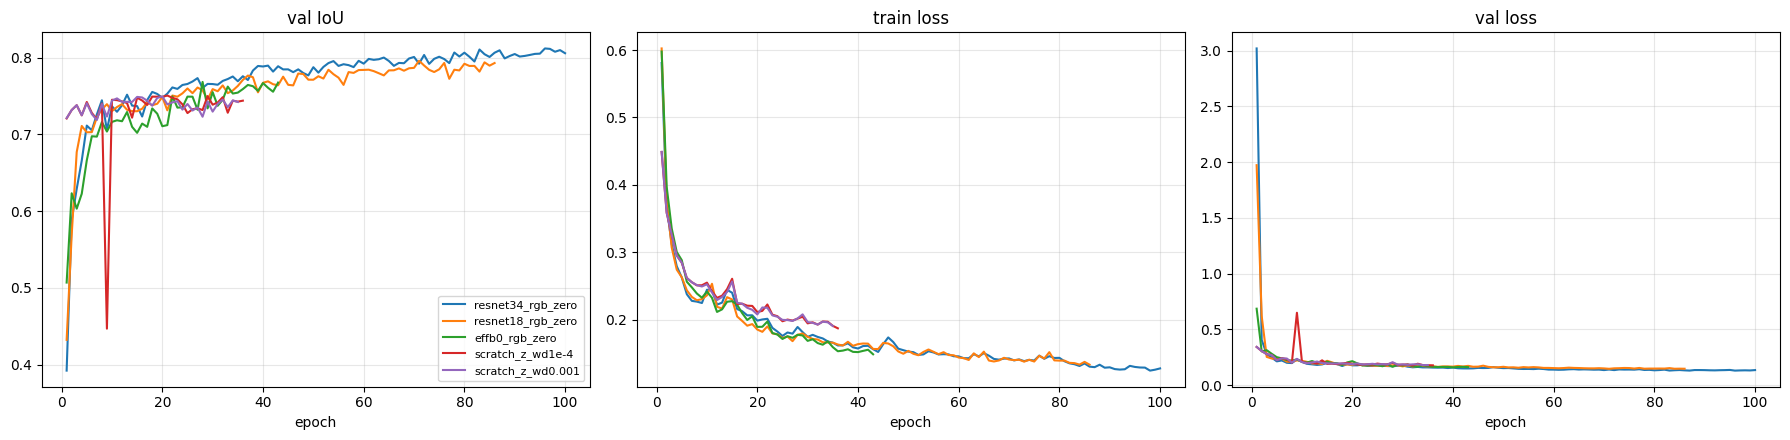

{'resnet34_rgb_zero': 96, 'resnet18_rgb_zero': 71, 'effb0_rgb_zero': 28, 'scratch_z_wd1e-4': 21, 'scratch_z_wd0.001': 20}
epochs run: {'resnet34_rgb_zero': 100, 'resnet18_rgb_zero': 86, 'effb0_rgb_zero': 43, 'scratch_z_wd1e-4': 36, 'scratch_z_wd0.001': 35}


In [15]:
seed_runs = {label: next(n for c, n in spec["runs"] if c["seed"] == 42) for label, spec in FINAL_RUNS.items()}
hists = {label: pd.read_csv(RUNS_DIR / name / "history.csv") for label, name in seed_runs.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for label, h in hists.items():
    axes[0].plot(h["epoch"], h["iou"], label=label)
    axes[1].plot(h["epoch"], h["train_loss"], label=label)
    axes[2].plot(h["epoch"], h["val_loss"], label=label)
axes[0].set_title("val IoU")
axes[1].set_title("train loss")
axes[2].set_title("val loss")
for a in axes:
    a.set_xlabel("epoch")
    a.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(RUNS_DIR / "curves_seed42.png", dpi=120)
plt.show()

print({label: int(h["iou"].idxmax() + 1) for label, h in hists.items()})
print("epochs run:", {label: len(h) for label, h in hists.items()})

In [16]:
def load_val_probs(label, seed=42):
    name = next(n for c, n in FINAL_RUNS[label]["runs"] if c["seed"] == seed)
    return np.load(RUNS_DIR / name / "val_probs.npy").astype(np.float32)


val_ids = [ids[i] for i in idx["val"]]
Yv_all = Ym[idx["val"]]
scratch_label = next(l for l in FINAL_RUNS if l.startswith("scratch"))

p_best = load_val_probs(BEST_LABEL)
p_scr = load_val_probs(scratch_label)
assert p_best.shape == Yv_all.shape == p_scr.shape

iou_best = per_image_iou(p_best, Yv_all)
iou_scr = per_image_iou(p_scr, Yv_all)
pred_b = p_best >= 0.5
gt_b = Yv_all >= 0.5
err = pd.DataFrame(dict(
    id=val_ids,
    water_pct=(Yv_all.reshape(len(Yv_all), -1).mean(axis=1) * 100).round(1),
    iou_best=iou_best.round(3),
    iou_scratch=iou_scr.round(3),
    delta=(iou_best - iou_scr).round(3),
    fp_px=np.logical_and(pred_b, ~gt_b).reshape(len(pred_b), -1).sum(axis=1),
    fn_px=np.logical_and(~pred_b, gt_b).reshape(len(pred_b), -1).sum(axis=1),
))
err.to_csv(RUNS_DIR / "val_per_image_errors.csv", index=False)

print("best pretrained:", BEST_LABEL, "| scratch control:", scratch_label)
print("median per-image IoU:", round(float(np.median(iou_best)), 3), "vs", round(float(np.median(iou_scr)), 3))
print("images with IoU < 0.5:", int((iou_best < 0.5).sum()), "vs", int((iou_scr < 0.5).sum()))
print("images where pretrained is better:", int((err["delta"] > 0).sum()), "of", len(err))
print()
print("10 worst images for the best pretrained model:")
print(err.sort_values("iou_best").head(10).to_string(index=False))
print()
print("correlation of per-image IoU with water percentage:", round(float(np.corrcoef(err["iou_best"], err["water_pct"])[0, 1]), 3))

best pretrained: resnet34_rgb_zero | scratch control: scratch_z_wd1e-4
median per-image IoU: 0.708 vs 0.637
images with IoU < 0.5: 13 vs 13
images where pretrained is better: 28 of 47

10 worst images for the best pretrained model:
 id  water_pct  iou_best  iou_scratch  delta  fp_px  fn_px
  7        0.2     0.000        0.000  0.000      0     38
141        0.2     0.000        0.026 -0.026      0     38
133        0.0     0.000        0.000  0.000      0      4
249        3.1     0.000        0.000  0.000      0    510
271        0.2     0.000        0.000  0.000      0     34
 28        3.4     0.076        0.074  0.002      4    507
 63        3.3     0.079        0.334 -0.255     11    501
 25        1.9     0.117        0.108  0.008     99    257
139        6.6     0.278        0.190  0.087     46    773
 87        4.1     0.309        0.666 -0.356     25    453

correlation of per-image IoU with water percentage: 0.495


### 16.3 Prediction visuals
- 4 worst and 2 best val images: RGB, truth, probability, errors (red false positive, blue false negative)

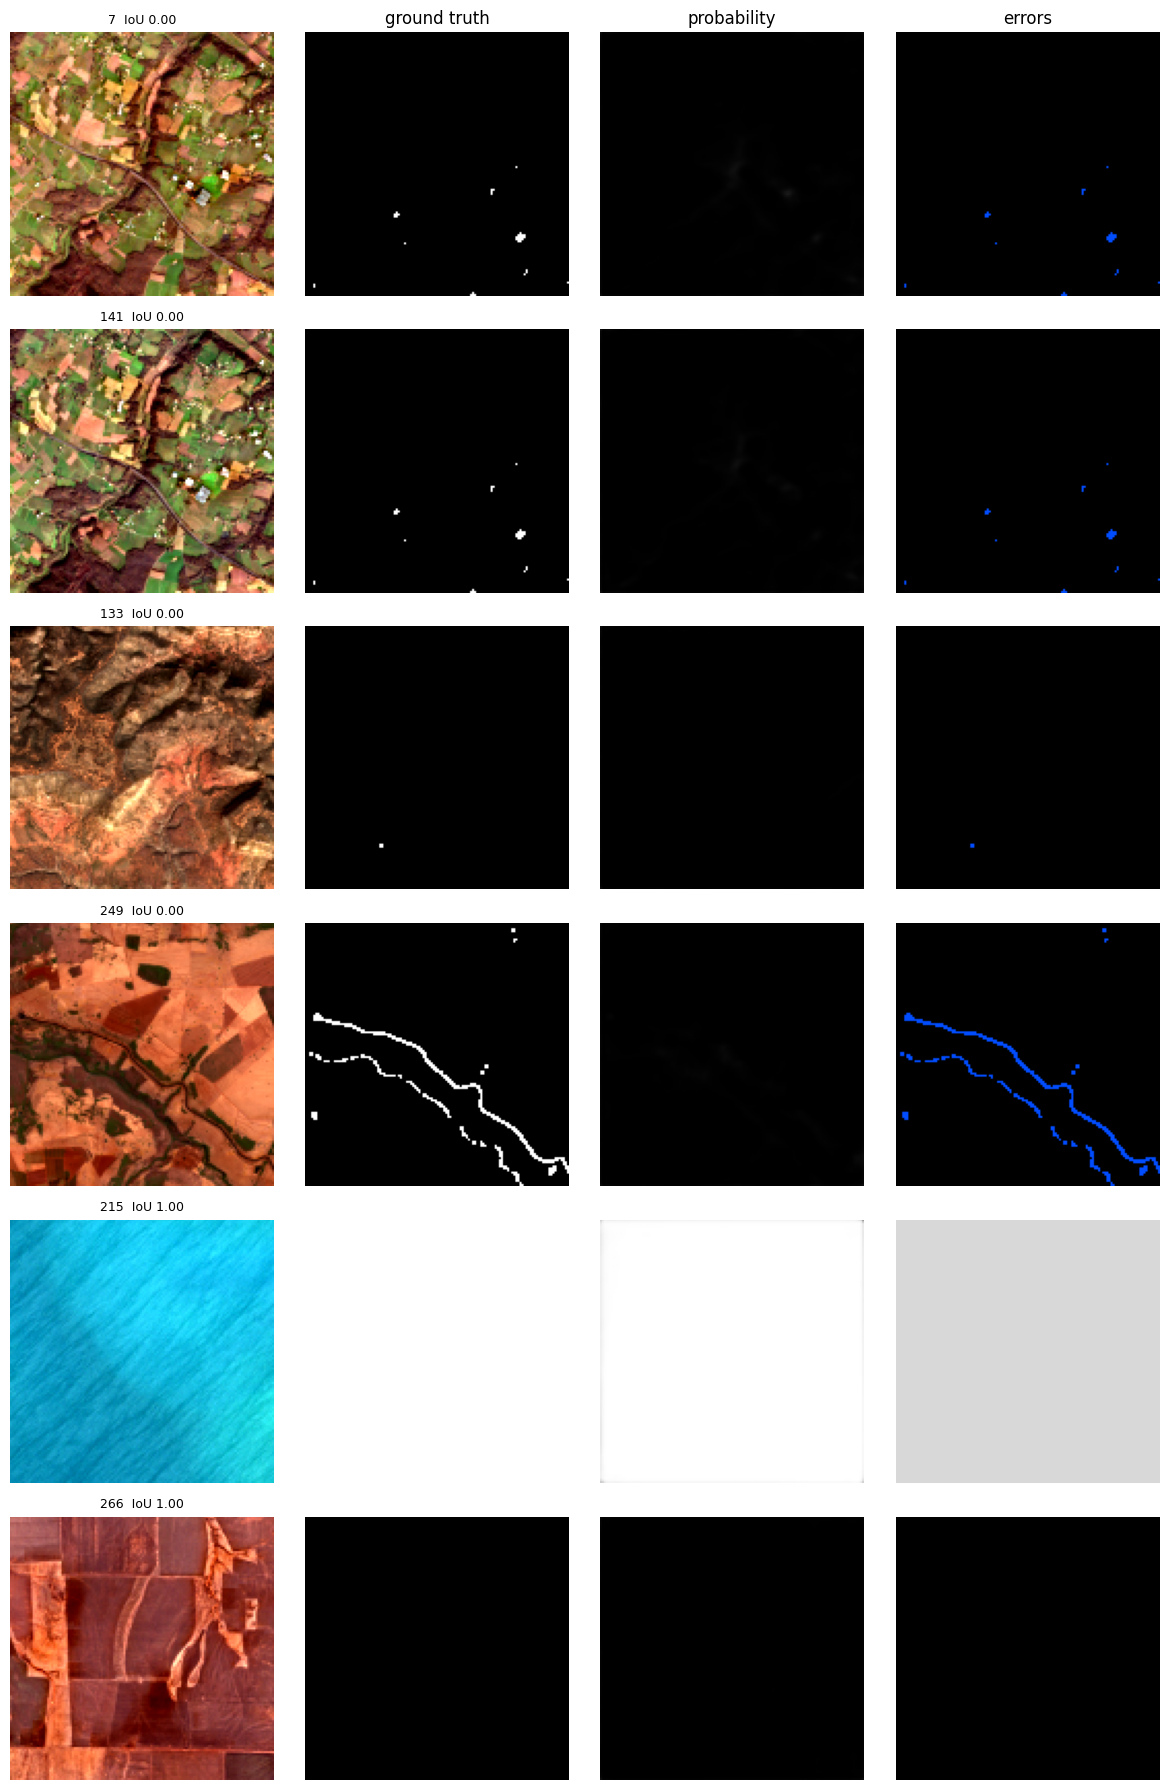

In [17]:
order = np.argsort(iou_best)
show = list(order[:4]) + list(order[-2:])

fig, axes = plt.subplots(len(show), 4, figsize=(12, 3 * len(show)))
for r, i in enumerate(show):
    gi = idx["val"][i]
    rgb = np.transpose(X12[gi][RGB_IDX], (1, 2, 0))
    lo, hi = np.percentile(rgb, 2), np.percentile(rgb, 98)
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-9), 0, 1)
    errmap = np.zeros((H, W, 3), dtype=np.float32)
    errmap[np.logical_and(pred_b[i], ~gt_b[i])] = [1, 0, 0]
    errmap[np.logical_and(~pred_b[i], gt_b[i])] = [0, 0.3, 1]
    errmap[np.logical_and(pred_b[i], gt_b[i])] = [0.85, 0.85, 0.85]
    for c, (img, title) in enumerate([(rgb, "RGB"), (gt_b[i], "ground truth"), (p_best[i], "probability"), (errmap, "errors")]):
        ax = axes[r, c]
        ax.imshow(img, cmap=None if img.ndim == 3 else "gray", vmin=None if img.ndim == 3 else 0, vmax=None if img.ndim == 3 else 1)
        ax.axis("off")
        if r == 0 and c > 0:
            ax.set_title(title)
    axes[r, 0].set_title(f"{val_ids[i]}  IoU {iou_best[i]:.2f}", fontsize=9)
plt.tight_layout()
plt.savefig(RUNS_DIR / "val_predictions.png", dpi=110)
plt.show()

## 13.3 Longer training for the selected model
### 13.3.1 Why ResNet34 (chosen on validation )
- Highest mean val IoU over 5 seeds: 0.7968 vs 0.7870 (EfficientNet-b0) and 0.7820 (ResNet18)



### 13.3.2 Longer runs
- LONG_BASE_LABEL picks the model to extend (change it to "effb0_rgb_zero" to extend EfficientNet-b0 instead)
- Seeds that were stopped by early stopping are reused, seeds that hit the old cap are retrained with max epochs 250
- RERUN_ALL = True retrains every seed
- Output to verify: capped seeds show a higher best epoch, no run ends at epoch 250 unless it is still improving

In [18]:
LONG_BASE_LABEL = "resnet34_rgb_zero"
LONG_LABEL = LONG_BASE_LABEL + "_long"
LONG_EPOCHS = 250
RERUN_ALL = False

long_runs = []
for cfg_old, name_old in FINAL_RUNS[LONG_BASE_LABEL]["runs"]:
    r_old = load_result(name_old)
    if not RERUN_ALL and r_old["epochs_run"] < cfg_old["epochs"]:
        long_runs.append((cfg_old, name_old))
        print(f"seed {cfg_old['seed']}: reused, early stopping at epoch {r_old['epochs_run']}")
        continue
    cfg_long = dict(cfg_old, epochs=LONG_EPOCHS)
    name_long = f"long{LONG_EPOCHS}_" + run_name_of(cfg_long)
    r = fit(name_long, cfg_long, DATA[cfg_long["data"]])
    v = r["val"]
    print(f"{name_long}: iou {v['iou']:.4f} f1 {v['f1']:.4f} best epoch {r['best_epoch']} of {r['epochs_run']} in {r['seconds']}s")
    long_runs.append((cfg_long, name_long))

FINAL_RUNS[LONG_LABEL] = dict(runs=long_runs)
print()
print({label: len(spec["runs"]) for label, spec in FINAL_RUNS.items()})

  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  10 train 0.2415 val 0.2185 iou 0.7294 best 0.7294@10
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  20 train 0.1965 val 0.1857 iou 0.7417 best 0.7444@14
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  30 train 0.1765 val 0.1735 iou 0.7567 best 0.7690@29
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  40 train 0.1623 val 0.1640 iou 0.7813 best 0.7813@40
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  50 train 0.1598 val 0.1509 iou 0.7868 best 0.7877@49
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  60 train 0.1520 val 0.1463 iou 0.7883 best 0.7910@51
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  70 train 0.1507 val 0.1479 iou 0.7926 best 0.7946@67
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  80 train 0.1461 val 0.1453 iou 0.7968 best 0.7968@80
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep  90 train 0.1379 val 0.1444 iou 0.7941 best 0.7978@87
  long250_resnet34_rgb_zero_z12_wd0.001_dw0_s42 ep 100 

### 13.3.3 Before and after


In [19]:
rows = []
for (c_o, n_o), (c_n, n_n) in zip(FINAL_RUNS[LONG_BASE_LABEL]["runs"], FINAL_RUNS[LONG_LABEL]["runs"]):
    ro, rn = load_result(n_o), load_result(n_n)
    rows.append(dict(
        seed=c_o["seed"],
        reused=(n_o == n_n),
        iou_old=ro["val"]["iou"],
        iou_long=rn["val"]["iou"],
        delta=rn["val"]["iou"] - ro["val"]["iou"],
        best_ep_old=ro["best_epoch"],
        best_ep_long=rn["best_epoch"],
        epochs_run_long=rn["epochs_run"],
        hit_new_cap=rn["epochs_run"] >= c_n["epochs"],
    ))
dfL = pd.DataFrame(rows)
assert np.isfinite(dfL[["iou_old", "iou_long"]].to_numpy()).all()
print(dfL.round(4).to_string(index=False))
print()
print(f"mean delta: {dfL['delta'].mean():.4f} | seeds improved: {int((dfL['delta'] > 0).sum())} of {len(dfL)} | runs at new cap: {int(dfL['hit_new_cap'].sum())}")

VAL_TABLE, VAL_NUM, RUNS_ALL = make_val_table()
show = [LONG_BASE_LABEL, LONG_LABEL] + [l for l in FINAL_RUNS if l.startswith("scratch")] + ["week1_baseline", "week1_engineered"]
print()
print(VAL_TABLE[VAL_TABLE["model"].isin(show)].to_string(index=False))
VAL_TABLE.to_csv(RUNS_DIR / "comparison_val.csv", index=False)
RUNS_ALL.to_csv(RUNS_DIR / "final_runs_val.csv", index=False)

 seed  reused  iou_old  iou_long   delta  best_ep_old  best_ep_long  epochs_run_long  hit_new_cap
   42   False   0.8118    0.7981 -0.0138           96            98              113        False
   43    True   0.7973    0.7973  0.0000           77            77               92        False
   44    True   0.7685    0.7685  0.0000           48            48               63        False
   45    True   0.7961    0.7961  0.0000           70            70               85        False
   46   False   0.8104    0.8018 -0.0086           96            67               82        False

mean delta: -0.0045 | seeds improved: 0 of 5 | runs at new cap: 0

                 model  n_seeds  params_M             iou              f1       precision          recall     iou_no_full  best_epoch
     resnet34_rgb_zero        5     24.46 0.7968 ± 0.0174 0.8868 ± 0.0109 0.9061 ± 0.0136 0.8685 ± 0.0100 0.7615 ± 0.0199        77.4
      scratch_z_wd1e-4        5      7.77 0.7484 ± 0.0042 0.8561 ± 0.0027 0.

In [20]:
test_runs = pd.read_csv(TEST_PATH)
if LONG_LABEL in set(test_runs["label"]):
    print("long label already scored")
else:
    Yt = np.ascontiguousarray(Ym[idx["test"]])
    recs = []
    for cfg, name in FINAL_RUNS[LONG_LABEL]["runs"]:
        old = test_runs[(test_runs["label"] == LONG_BASE_LABEL) & (test_runs["run"] == name)]
        if len(old):
            row = old.iloc[0].to_dict()
            row["label"] = LONG_LABEL
            recs.append(row)
            continue
        Xt_run = torch.from_numpy(np.ascontiguousarray(DATA[cfg["data"]]["X"][idx["test"]]))
        model = build_model(cfg, pretrained=False).to(device)
        model.load_state_dict(torch.load(RUNS_DIR / name / "best.pt", map_location=device))
        probs, _ = predict(model, Xt_run)
        assert probs.shape == Yt.shape and 0.0 <= float(probs.min()) and float(probs.max()) <= 1.0
        m = pooled_metrics(probs, Yt)
        m["iou_no_full"] = iou_without_full_water(probs, Yt)
        recs.append(dict(label=LONG_LABEL, seed=cfg["seed"], run=name, **m))
        del model
        torch.cuda.empty_cache()
    test_runs = pd.concat([test_runs, pd.DataFrame(recs)], ignore_index=True)
    test_runs.to_csv(TEST_PATH, index=False)

rows = []
for label, g in test_runs.groupby("label", sort=False):
    rows.append(dict(model=label, n_seeds=len(g), iou=pm(g["iou"]), f1=pm(g["f1"]), precision=pm(g["precision"]), recall=pm(g["recall"])))
TEST_TABLE = pd.DataFrame(rows)
print(TEST_TABLE.to_string(index=False))

                 model  n_seeds             iou              f1       precision          recall
     resnet34_rgb_zero        5 0.6966 ± 0.0265 0.8209 ± 0.0187 0.8889 ± 0.0178 0.7641 ± 0.0408
     resnet18_rgb_zero        5 0.6896 ± 0.0271 0.8161 ± 0.0193 0.8877 ± 0.0216 0.7570 ± 0.0444
        effb0_rgb_zero        5 0.6972 ± 0.0318 0.8212 ± 0.0222 0.8937 ± 0.0150 0.7614 ± 0.0475
      scratch_z_wd1e-4        5 0.6113 ± 0.0098 0.7587 ± 0.0075 0.8807 ± 0.0173 0.6669 ± 0.0187
     scratch_z_wd0.001        5 0.6208 ± 0.0177 0.7659 ± 0.0135 0.8766 ± 0.0112 0.6806 ± 0.0247
resnet34_rgb_zero_long        5 0.6908 ± 0.0216 0.8170 ± 0.0154 0.8957 ± 0.0080 0.7515 ± 0.0286


### 16.4 Analysis

- Pretraining helped. ResNet34 got 0.797 val IoU against 0.748 for the scratch U-Net trained the same way, and 0.757 for the best Week 1 model.
- On the test set the gap was bigger: 0.697 vs 0.611.
- The scratch controls scored the same as the Week 1 baseline (0.748 vs 0.749), so z-scoring and the higher weight decay did not help. The improvement comes from the pretrained encoder.
- The three encoders are close (ResNet34 0.797, EfficientNet-b0 0.787, ResNet18 0.782). The gaps are smaller than the seed std (about 0.015), so I can't say one is really better.
- avg and rgb_zero for the first layer also tied (0.7868 for both). Both use all 12 channels, the name only describes how the first layer starts.
- Training longer (250 epochs) did not help (0.797 vs 0.792), so 100 epochs was enough.
- The pretrained models are less stable than scratch. Their std over seeds is about 0.015, against 0.003 for the scratch controls.
- The 10 worst val images all have under 7% water and the model mostly misses water pixels instead of adding extra ones. I think small water bodies are the main problem (not tested).
- Limits: only 47 val and 46 test images, and every model drops by about 0.1 from val to test. I did not reach 0.8 on the mean, only on single seeds.

## 17. Comparison with Week 1

All rows use the same split, augmentation and early stopping, with 5 seeds. The scratch controls use the Week 1 U-Net on z-scored input.

### Validation (mean ± std)
| Model | IoU | F1 | Precision | Recall |
|---|---|---|---|---|
| ResNet34 | 0.797 ± 0.017 | 0.887 | 0.906 | 0.869 |
| EfficientNet-b0 | 0.787 ± 0.013 | 0.881 | 0.909 | 0.855 |
| ResNet18 | 0.782 ± 0.016 | 0.878 | 0.905 | 0.852 |
| Unet engineered | 0.757 ± 0.002 | 0.862 | 0.922 | 0.810 |
| Scratch control (wd 1e-3) | 0.750 ± 0.003 | 0.857 | 0.901 | 0.817 |
| Unet baseline | 0.749 ± 0.014 | 0.856 | 0.895 | 0.822 |
| Scratch control (wd 1e-4) | 0.748 ± 0.004 | 0.856 | 0.906 | 0.813 |

### Test (scored once)
| Model | IoU | F1 |
|---|---|---|
| EfficientNet-b0 | 0.697 ± 0.032 | 0.821 |
| ResNet34 | 0.697 ± 0.027 | 0.821 |
| ResNet18 | 0.690 ± 0.027 | 0.816 |
| Scratch control (wd 1e-3) | 0.621 ± 0.018 | 0.766 |
| Scratch control (wd 1e-4) | 0.611 ± 0.010 | 0.759 |

The Unet models were never scored on test.

### Summary
- All pretrained models beat every scratch model on both sets.
- The smallest gain is ResNet18 over Week 1 engineered, +0.025 val IoU.
- The gain comes mostly from recall (about 0.86 vs 0.81), precision stays about the same.
- Pretrained models take longer to train (47 to 77 epochs vs 11 to 19) and are less stable between seeds.
- EfficientNet-b0 has only 6.3M parameters and still matches ResNet34 on test.
- Caveat: weight decay and the first-layer strategy were picked on the val set, so the val numbers are slightly optimistic.